#  Predicción de Innovación Empresarial en Colombia
### Enterprise Survey 2023 — Banco Mundial
**Universidad Externado de Colombia · IA con Aplicaciones en Economía I**

---

**Pregunta de investigación:** ¿Qué características de una empresa colombiana permiten predecir si innovará en productos o servicios?

| Variable | Descripción | Rol |
|----------|-------------|-----|
| `h1` | ¿Introdujo nuevos productos/servicios? (1=Sí · 2=No) |  Target |
| `b8` | Certificación de calidad internacional | Feature |
| `b6` | Nº trabajadores al inicio (proxy tamaño) | Feature |
| `d3a/b/c` | % ventas nacionales / exp. indirectas / exp. directas | Feature |
| `e32` | Cambio percibido en competencia | Feature |
| `e6` | Usa tecnología licenciada extranjera | Feature |
| `c22b` | Tiene sitio web o redes sociales | Feature |

**Estructura:**
```
1. Carga de datos
2. Limpieza y tratamiento de valores especiales
3. Transformación y Feature Engineering
4. Análisis Exploratorio (EDA)
5. Preparación para ML (split + escalado)
6. Modelos supervisados: Logit, Random Forest, Gradient Boosting, KNN
7. Reducción de dimensionalidad: PCA
8. Clustering no supervisado: K-Means
9. Comparación y selección del mejor modelo
```

## 1. Carga de datos

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    precision_recall_curve
)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_DISPONIBLE = True
except ImportError:
    SMOTE_DISPONIBLE = False

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

print('Librerias cargadas.')


Librerias cargadas.


In [4]:
#── Carga del archivo Stata (.dta)

RUTA = '/content/Colombia-2023-full-data (3).dta'

df_raw = pd.read_stata(RUTA, convert_categoricals=False)
print(f'Dataset cargado: {df_raw.shape[0]:,} empresas × {df_raw.shape[1]:,} variables')

Dataset cargado: 919 empresas × 356 variables


In [5]:
# ── Selección de variables del proyecto

VARS = ['h1','b8','b6','d3a','d3b','d3c','e32','e6','c22b']
TARGET   = 'h1'
FEATURES = [v for v in VARS if v != TARGET]

df = df_raw[VARS].copy()
print(f'Subconjunto: {df.shape}')
print()
display(df.head())

Subconjunto: (919, 9)



,h1,b8,b6,d3a,d3b,d3c,e32,e6,c22b
0,2,2,-9,99,0,1,1,2,1
1,2,2,-9,70,0,30,2,2,1
2,2,1,20,100,0,0,1,2,1
3,2,1,10,100,0,0,3,2,1
4,2,2,6,100,0,0,2,2,1


## 2. Limpieza y tratamiento de valores especiales

El cuestionario del Enterprise Survey usa **códigos especiales** para respuestas
no estándar que NO son valores numéricos válidos:

| Código | Significado |
|--------|-------------|
| `-9` | No sabe / No responde |
| `-6` | En proceso (aún sin resultado) |
| `-7` | No aplica |
| `-8` | Se rehusó a responder |

Todos se reemplazan por `NaN` antes de cualquier análisis.

In [6]:

CODIGOS_ESPECIALES = [-9, -7, -6, -8]

print(f'{"Variable":<8}  {"NaN":>5}  {"-9":>5}  {"-6":>5}  {"-7":>5}  {"-8":>5}')
print('─' * 42)
for col in VARS:
    nans = df[col].isna().sum()
    c = {k: (df[col] == k).sum() for k in CODIGOS_ESPECIALES}
    print(f'{col:<8}  {nans:>5}  {c[-9]:>5}  {c[-6]:>5}  {c[-7]:>5}  {c[-8]:>5}')

Variable    NaN     -9     -6     -7     -8
──────────────────────────────────────────
h1            0      0      0      0      0
b8            0      3      8      0      0
b6            0     63      0      0      0
d3a           0      2      0      0      0
d3b           0      2      0      0      0
d3c           0      2      0      0      0
e32           0      3      0      0      0
e6            0      5      0      0      0
c22b          0      2      0      0      0


In [7]:
#  Reemplazar códigos especiales → NaN


for col in VARS:
    df[col] = df[col].replace(CODIGOS_ESPECIALES, np.nan)

print('NaN por columna tras reemplazo:')
display(df.isnull().sum().rename('NaN').to_frame().T)

NaN por columna tras reemplazo:


,h1,b8,b6,d3a,d3b,d3c,e32,e6,c22b
NaN,0,11,63,2,2,2,3,5,2


In [8]:

suma_d3 = df[['d3a','d3b','d3c']].sum(axis=1)
ok = (suma_d3.dropna() == 100).mean() * 100
print(f'd3a+d3b+d3c = 100: {ok:.1f}%  ' if ok > 99 else f' Inconsistencias: {100-ok:.1f}%')

d3a+d3b+d3c = 100: 99.8%  


In [9]:
#  Eliminar filas con NaN y duplicados


n_antes = len(df)
df = df.dropna().reset_index(drop=True)
n_dup = df.duplicated().sum()
if n_dup > 0:
    df = df.drop_duplicates().reset_index(drop=True)

print(f'Observaciones originales: {n_antes}')
print(f'Observaciones eliminadas: {n_antes - len(df)}  ({(n_antes-len(df))/n_antes*100:.1f}%)')
print(f'Duplicados eliminados:    {n_dup}')
print(f'Dataset final:            {len(df)} observaciones')

Observaciones originales: 919
Observaciones eliminadas: 572  (62.2%)
Duplicados eliminados:    496
Dataset final:            347 observaciones


## 3. Transformación y Feature Engineering

Se crean nuevas variables con justificación económica para enriquecer el modelo:

In [10]:

#  Recodificar target: h1 → binaria 0/1

df['innova'] = (df['h1'] == 1).astype(int)

vc = df['innova'].value_counts()
print('Distribucion del TARGET (innova):')
print(f'  Innovo     (1): {vc[1]:>4}  ({vc[1]/len(df)*100:.1f}%)')
print(f'  No innovo  (0): {vc[0]:>4}  ({vc[0]/len(df)*100:.1f}%)')
print()
print('Dataset desbalanceado — clase positiva aprox. 13%.')
print('Dado que la muestra es pequena, NO se aplica undersampling (reduciria aun mas los datos).')
print('Se usa class_weight="balanced" en los modelos que lo soporten.')
print('Si se quisiera aplicar una tecnica de remuestreo, la recomendada es oversampling (SMOTE).')
print('Metricas principales: F1-Score (clase 1) y ROC-AUC.')


Distribucion del TARGET (innova):
  Innovo     (1):   81  (23.3%)
  No innovo  (0):  266  (76.7%)

Dataset desbalanceado — clase positiva aprox. 13%.
Dado que la muestra es pequena, NO se aplica undersampling (reduciria aun mas los datos).
Se usa class_weight="balanced" en los modelos que lo soporten.
Si se quisiera aplicar una tecnica de remuestreo, la recomendada es oversampling (SMOTE).
Metricas principales: F1-Score (clase 1) y ROC-AUC.


In [11]:
#  Feature Engineering


df['log_b6'] = np.log1p(df['b6'])


df['pct_exporta'] = df['d3b'] + df['d3c']


df['exportadora'] = (df['pct_exporta'] > 0).astype(int)


df['tiene_cert'] = (df['b8'] == 1).astype(int)


df['es_digital'] = (df['c22b'] == 1).astype(int)


df['usa_tec_ext'] = (df['e6'] == 1).astype(int)


e32_dummies = pd.get_dummies(df['e32'], prefix='comp', drop_first=True).astype(int)
df = pd.concat([df, e32_dummies], axis=1)

print('Variables creadas:')
nuevas = ['log_b6','pct_exporta','exportadora','tiene_cert',
          'es_digital','usa_tec_ext'] + list(e32_dummies.columns)
for v in nuevas:
    print(f'  {v}: media = {df[v].mean():.3f}')

Variables creadas:
  log_b6: media = 2.477
  pct_exporta: media = 7.807
  exportadora: media = 0.305
  tiene_cert: media = 0.242
  es_digital: media = 0.804
  usa_tec_ext: media = 0.193
  comp_2.0: media = 0.092
  comp_3.0: media = 0.340


In [12]:
# Definir X e y
FEATURES_ML = [
    'log_b6',       # tamaño inicial (log)
    'd3a',          # % ventas nacionales
    'pct_exporta',  # % exportaciones totales
    'tiene_cert',   # dummy: certificación
    'es_digital',   # dummy: digitalización
    'usa_tec_ext',  # dummy: tecnología extranjera
    'comp_2.0',     # dummy: menos competencia (ref = más competencia)
    'comp_3.0',     # dummy: sin cambio en competencia
]

X = df[FEATURES_ML].copy()
y = df['innova'].copy()

print(f'X: {X.shape}  →  {len(FEATURES_ML)} features, {len(X)} obs.')
print(f'y: {y.sum()} positivos ({y.mean()*100:.1f}%)')
print()
display(X.describe().round(2))

X: (347, 8)  →  8 features, 347 obs.
y: 81 positivos (23.3%)



,log_b6,d3a,pct_exporta,tiene_cert,es_digital,usa_tec_ext,comp_2.0,comp_3.0
count,347.00,347.00,347.00,347.00,347.0,347.00,347.00,347.00
mean,2.48,92.19,7.81,0.24,0.8,0.19,0.09,0.34
std,1.11,19.24,19.24,0.43,0.4,0.40,0.29,0.47
min,0.69,0.00,0.00,0.00,0.0,0.00,0.00,0.00
25%,1.61,95.00,0.00,0.00,1.0,0.00,0.00,0.00
50%,2.40,100.00,0.00,0.00,1.0,0.00,0.00,0.00
75%,3.04,100.00,5.00,0.00,1.0,0.00,0.00,1.00
max,7.60,100.00,100.00,1.00,1.0,1.00,1.00,1.00


## 4. Análisis Exploratorio de Datos (EDA)

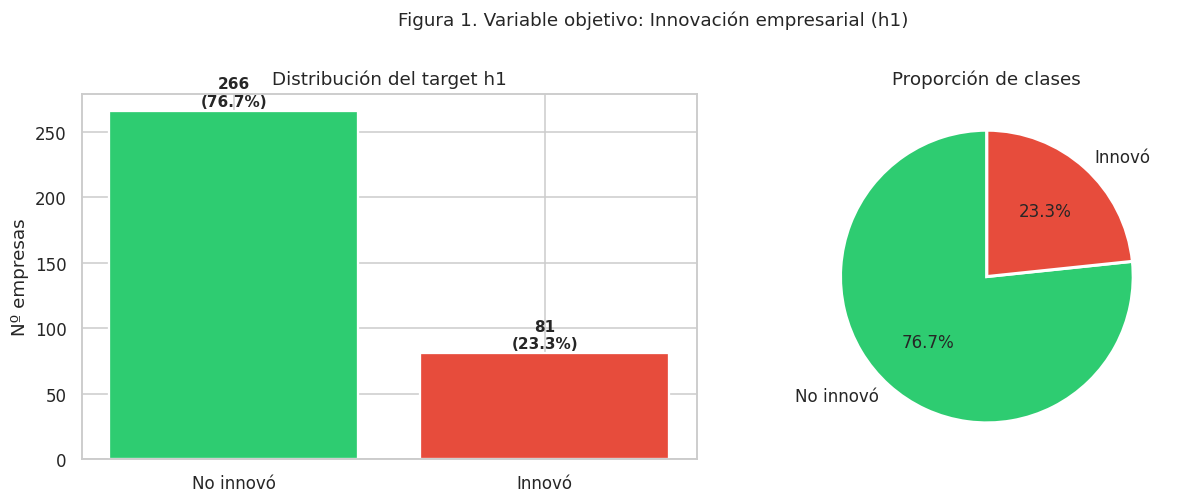

📌 Insight: Solo el 12.7% de las empresas colombianas innovó.
   Refleja la baja cultura de innovación en pymes — un desafío estructural.
   El desbalance requiere métricas específicas: F1-Score y ROC-AUC.


In [13]:
# ── Fig. 1: Distribución del target

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
df['innova_lbl'] = df['innova'].map({1:'Innovó', 0:'No innovó'})

conteo = df['innova_lbl'].value_counts()
cols = ['#2ecc71','#e74c3c']

bars = axes[0].bar(conteo.index, conteo.values, color=cols, edgecolor='white', lw=1.5)
axes[0].set_ylabel('Nº empresas'); axes[0].set_title('Distribución del target h1')
for b, v in zip(bars, conteo.values):
    axes[0].text(b.get_x()+b.get_width()/2, v+4,
                 f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')

axes[1].pie(conteo.values, labels=conteo.index, autopct='%1.1f%%',
            colors=cols, startangle=90, wedgeprops=dict(edgecolor='white', lw=2))
axes[1].set_title('Proporción de clases')

plt.suptitle('Figura 1. Variable objetivo: Innovación empresarial (h1)', fontsize=12, y=1.01)
plt.tight_layout(); plt.savefig('fig1_target.png', bbox_inches='tight'); plt.show()

print('📌 Insight: Solo el 12.7% de las empresas colombianas innovó.')
print('   Refleja la baja cultura de innovación en pymes — un desafío estructural.')
print('   El desbalance requiere métricas específicas: F1-Score y ROC-AUC.')

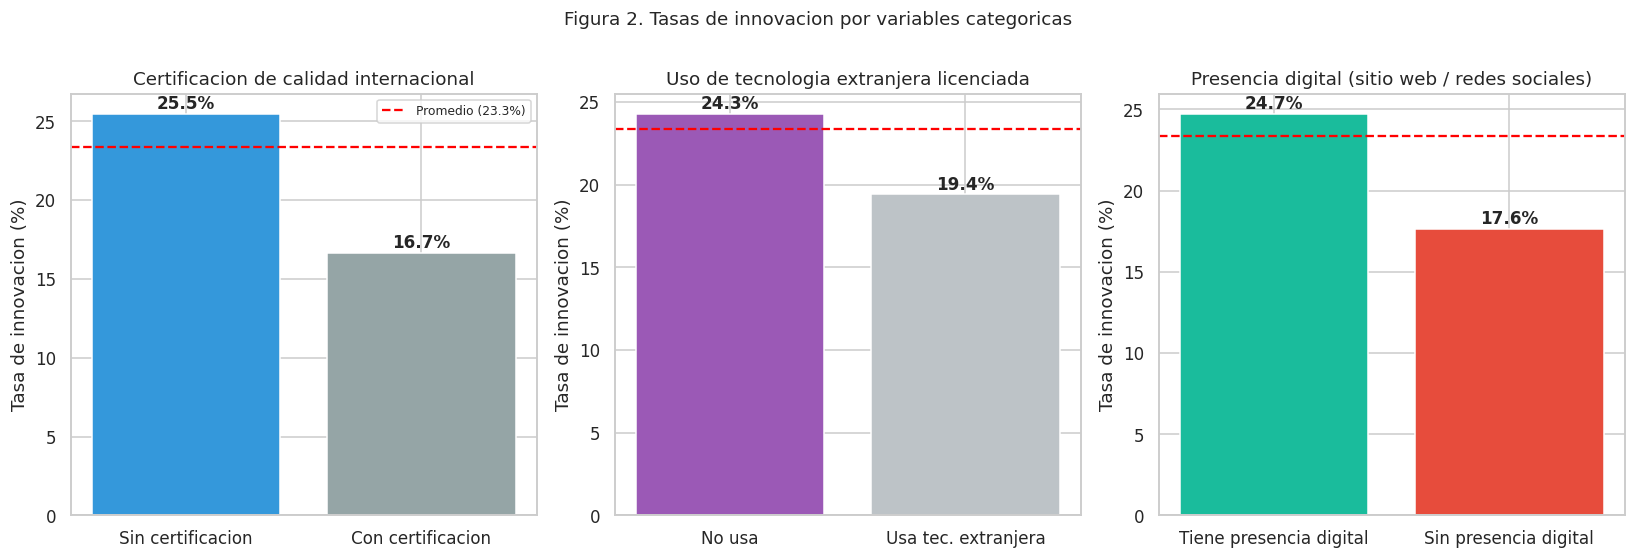

Insights:
  Empresas con tecnologia extranjera innovan 24.3% vs 19.4% sin ella.
  Empresas digitales: 24.7% vs no digitales 17.6%.
  La adopcion de tecnologia externa impulsa la capacidad innovadora.


In [14]:

# ── Fig. 2: Tasas de innovacion por variables categoricas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
prom = y.mean() * 100

# Certificacion internacional
df['b8_lbl'] = df['b8'].map({1:'Con certificacion', 2:'Sin certificacion'})
t_b8 = df.groupby('b8_lbl')['innova'].mean().mul(100).sort_values(ascending=False)
axes[0].bar(t_b8.index, t_b8.values, color=['#3498db','#95a5a6'], edgecolor='white')
axes[0].axhline(prom, color='red', ls='--', lw=1.5, label=f'Promedio ({prom:.1f}%)')
axes[0].set_title('Certificacion de calidad internacional')
axes[0].set_ylabel('Tasa de innovacion (%)')
axes[0].legend(fontsize=8)
for i, v in enumerate(t_b8.values):
    axes[0].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Tecnologia extranjera
df['e6_lbl'] = df['e6'].map({1:'Usa tec. extranjera', 2:'No usa'})
t_e6 = df.groupby('e6_lbl')['innova'].mean().mul(100).sort_values(ascending=False)
axes[1].bar(t_e6.index, t_e6.values, color=['#9b59b6','#bdc3c7'], edgecolor='white')
axes[1].axhline(prom, color='red', ls='--', lw=1.5)
axes[1].set_title('Uso de tecnologia extranjera licenciada')
axes[1].set_ylabel('Tasa de innovacion (%)')
for i, v in enumerate(t_e6.values):
    axes[1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Digitalizacion
df['c22b_lbl'] = df['c22b'].map({1:'Tiene presencia digital', 2:'Sin presencia digital'})
t_c22b = df.groupby('c22b_lbl')['innova'].mean().mul(100).sort_values(ascending=False)
axes[2].bar(t_c22b.index, t_c22b.values, color=['#1abc9c','#e74c3c'], edgecolor='white')
axes[2].axhline(prom, color='red', ls='--', lw=1.5)
axes[2].set_title('Presencia digital (sitio web / redes sociales)')
axes[2].set_ylabel('Tasa de innovacion (%)')
for i, v in enumerate(t_c22b.values):
    axes[2].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Figura 2. Tasas de innovacion por variables categoricas', fontsize=12, y=1.01)
plt.tight_layout(); plt.savefig('fig2_categoricas.png', bbox_inches='tight'); plt.show()

print('Insights:')
print(f'  Empresas con tecnologia extranjera innovan {t_e6.iloc[0]:.1f}% vs {t_e6.iloc[1]:.1f}% sin ella.')
print(f'  Empresas digitales: {t_c22b.iloc[0]:.1f}% vs no digitales {t_c22b.iloc[1]:.1f}%.')
print('  La adopcion de tecnologia externa impulsa la capacidad innovadora.')


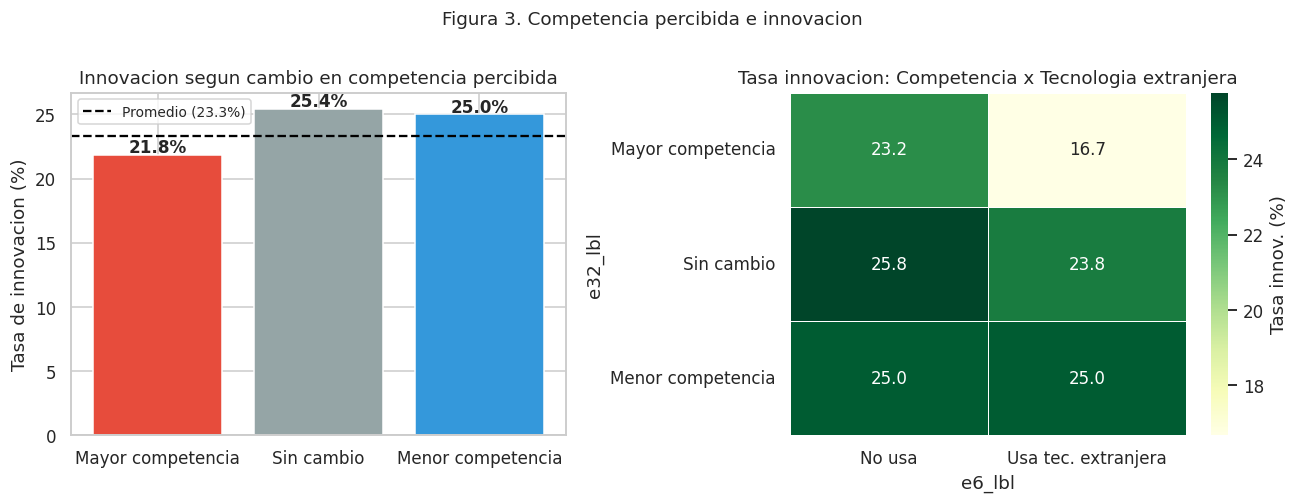

Insight: Empresas que perciben MENOS competencia tienen mayor tasa de
  innovacion. Consistente con teoria: cuando los margenes son comodos,
  hay mas recursos para invertir en nuevos productos.


In [21]:

#  Competencia percibida e innovacion
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

df['e32_lbl'] = df['e32'].map({1:'Mayor competencia', 2:'Menor competencia', 3:'Sin cambio'})
orden = ['Mayor competencia','Sin cambio','Menor competencia']
t_e32 = df.groupby('e32_lbl')['innova'].mean().reindex(orden).mul(100)

axes[0].bar(t_e32.index, t_e32.values, color=['#e74c3c','#95a5a6','#3498db'], edgecolor='white')
axes[0].axhline(prom, color='black', ls='--', lw=1.5, label=f'Promedio ({prom:.1f}%)')
axes[0].set_ylabel('Tasa de innovacion (%)')
axes[0].set_title('Innovacion segun cambio en competencia percibida')
axes[0].legend(fontsize=9)
for i, v in enumerate(t_e32.values):
    axes[0].text(i, v+0.2, f'{v:.1f}%', ha='center', fontweight='bold')

pivot = df.pivot_table(values='innova', index='e32_lbl',
                       columns='e6_lbl', aggfunc='mean').mul(100)
pivot = pivot.reindex(index=orden)
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGn', linewidths=0.5,
            ax=axes[1], cbar_kws={'label':'Tasa innov. (%)'})
axes[1].set_title('Tasa innovacion: Competencia x Tecnologia extranjera')

plt.suptitle('Figura 3. Competencia percibida e innovacion', fontsize=12, y=1.01)
plt.tight_layout(); plt.savefig('fig3_competencia.png', bbox_inches='tight'); plt.show()

print('Insight: Empresas que perciben MENOS competencia tienen mayor tasa de')
print('  innovacion. Consistente con teoria: cuando los margenes son comodos,')
print('  hay mas recursos para invertir en nuevos productos.')


UnboundLocalError: cannot access local variable 'boxprops' where it is not associated with a value

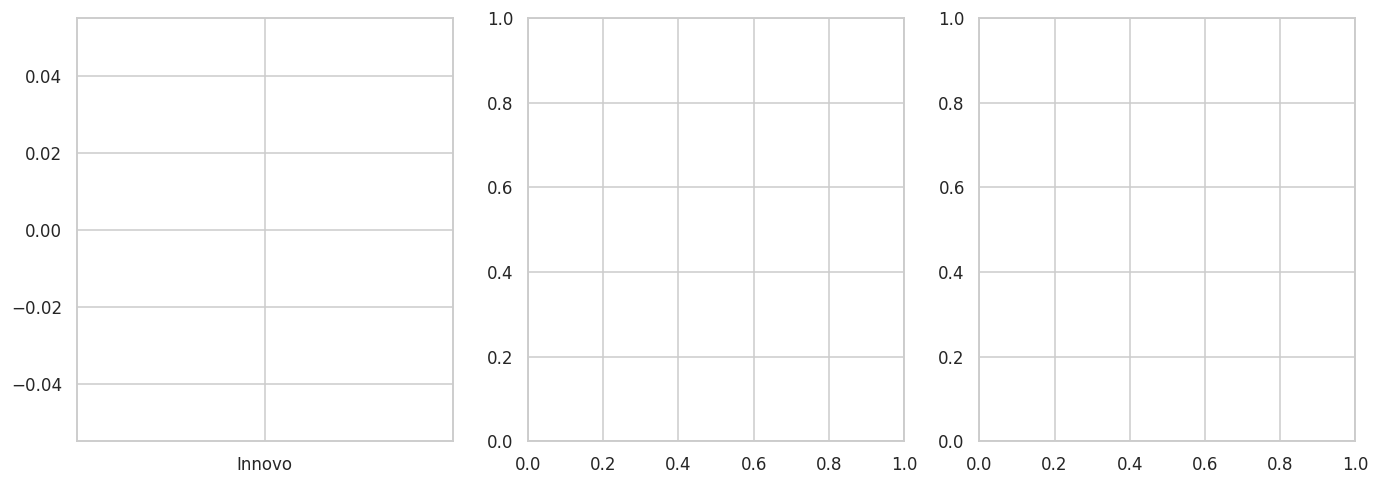

In [22]:

#  Variables numericas por grupo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

LABELS_VARS = {
    'log_b6':      'Tamano inicial (log trabajadores)',
    'd3a':         'Porcentaje de ventas nacionales',
    'pct_exporta': 'Porcentaje de exportaciones totales',
}

for ax, (var, titulo) in zip(axes, LABELS_VARS.items()):
    sns.boxplot(data=df, x='innova_lbl', y=var, order=['Innovo','No innovo'],
                palette=['#2ecc71','#e74c3c'], ax=ax, linewidth=1.2)
    ax.set_title(titulo)
    ax.set_xlabel('')
    ax.set_ylabel(titulo)

plt.suptitle('Figura 4. Variables numericas segun innovacion', fontsize=12, y=1.01)
plt.tight_layout(); plt.savefig('fig4_numericas.png', bbox_inches='tight'); plt.show()

for var in ['log_b6','d3a','pct_exporta']:
    m_i  = df[df['innova']==1][var].median()
    m_ni = df[df['innova']==0][var].median()
    print(f'{LABELS_VARS[var]:<45}: innovo={m_i:.2f}  no innovo={m_ni:.2f}')


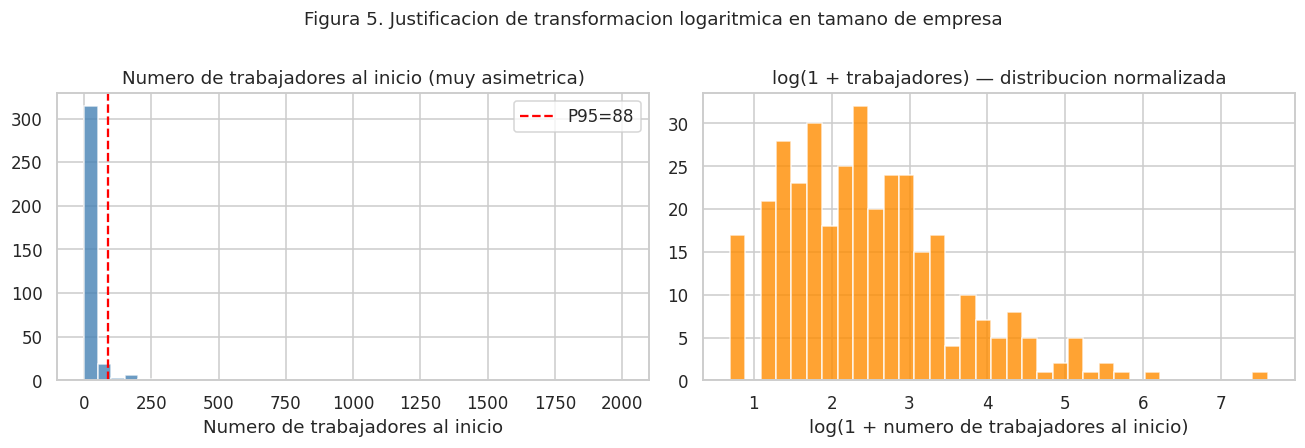

Asimetria original: 14.96  ->  log(trabajadores): 0.86


In [17]:

#  Transformacion log en tamano de empresa (numero de trabajadores)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['b6'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['b6'].quantile(0.95), color='red', ls='--',
                label=f'P95={df["b6"].quantile(0.95):.0f}')
axes[0].set_title('Numero de trabajadores al inicio (muy asimetrica)')
axes[0].set_xlabel('Numero de trabajadores al inicio')
axes[0].legend()

axes[1].hist(df['log_b6'], bins=35, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].set_title('log(1 + trabajadores) — distribucion normalizada')
axes[1].set_xlabel('log(1 + numero de trabajadores al inicio)')

plt.suptitle('Figura 5. Justificacion de transformacion logaritmica en tamano de empresa', fontsize=12, y=1.01)
plt.tight_layout(); plt.savefig('fig5_log_b6.png', bbox_inches='tight'); plt.show()

print(f'Asimetria original: {df["b6"].skew():.2f}  ->  log(trabajadores): {df["log_b6"].skew():.2f}')


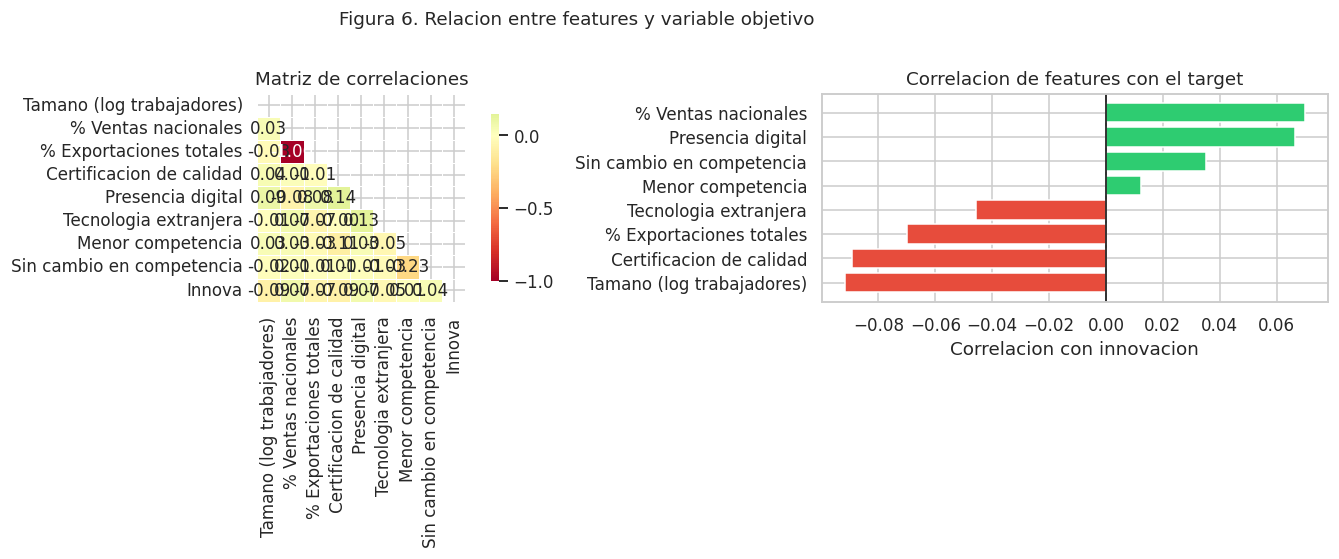

Variables con mayor correlacion con innovacion:
  Tamano (log trabajadores)          : r = -0.092
  Certificacion de calidad           : r = -0.089
  % Exportaciones totales            : r = -0.070
  % Ventas nacionales                : r = +0.070


In [18]:

#  Correlaciones con el target

NOMBRES_FEATURES = {
    'log_b6':     'Tamano (log trabajadores)',
    'd3a':        '% Ventas nacionales',
    'pct_exporta':'% Exportaciones totales',
    'tiene_cert': 'Certificacion de calidad',
    'es_digital': 'Presencia digital',
    'usa_tec_ext':'Tecnologia extranjera',
    'comp_2.0':   'Menor competencia',
    'comp_3.0':   'Sin cambio en competencia',
}

corr_df = X.copy()
corr_df['innova'] = y.values
corr_df_renamed = corr_df.rename(columns=NOMBRES_FEATURES)
corr_df_renamed = corr_df_renamed.rename(columns={'innova': 'Innova'})
corr_mat_r = corr_df_renamed.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mask = np.triu(np.ones_like(corr_mat_r, dtype=bool))
sns.heatmap(corr_mat_r, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, square=True, ax=axes[0],
            cbar_kws={'shrink':0.8})
axes[0].set_title('Matriz de correlaciones')

corr_mat = corr_df.corr()
corr_y = corr_mat['innova'].drop('innova').rename(index=NOMBRES_FEATURES).sort_values()
colores_c = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_y.values]
axes[1].barh(corr_y.index, corr_y.values, color=colores_c, edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_xlabel('Correlacion con innovacion')
axes[1].set_title('Correlacion de features con el target')

plt.suptitle('Figura 6. Relacion entre features y variable objetivo', fontsize=12, y=1.01)
plt.tight_layout(); plt.savefig('fig6_correlaciones.png', bbox_inches='tight'); plt.show()

print('Variables con mayor correlacion con innovacion:')
top = corr_mat['innova'].drop('innova').abs().sort_values(ascending=False)
for v, r in top.head(4).items():
    nombre_legible = NOMBRES_FEATURES.get(v, v)
    print(f'  {nombre_legible:<35}: r = {corr_mat["innova"][v]:+.3f}')


## 5. Preparación para Modelos de ML

In [19]:
# Escalado de variables continuas


COLS_CONT = ['log_b6', 'd3a', 'pct_exporta']

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[COLS_CONT] = scaler.fit_transform(X[COLS_CONT])

print('Variables escaladas (media ≈ 0, std ≈ 1):')
display(X_scaled[COLS_CONT].describe().round(3))

Variables escaladas (media ≈ 0, std ≈ 1):


,log_b6,d3a,pct_exporta
count,347.000,347.000,347.000
mean,-0.000,0.000,0.000
std,1.001,1.001,1.001
min,-1.605,-4.799,-0.406
25%,-0.780,0.146,-0.406
50%,-0.071,0.406,-0.406
75%,0.511,0.406,-0.146
max,4.613,0.406,4.799


In [23]:
#  Train / Test split estratificado

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'X_train: {X_train.shape}  →  {y_train.sum()} positivos ({y_train.mean()*100:.1f}%)')
print(f'X_test:  {X_test.shape}   →  {y_test.sum()} positivos ({y_test.mean()*100:.1f}%)')
print(' Proporción de clases conservada en ambas particiones.')

X_train: (277, 8)  →  65 positivos (23.5%)
X_test:  (70, 8)   →  16 positivos (22.9%)
 Proporción de clases conservada en ambas particiones.


## 6. Modelos Supervisados

Se implementan cuatro modelos de clasificación:

| Modelo | Justificación económica |
|--------|------------------------|
| **Logit** | Modelo base interpretable: cuantifica el efecto marginal de cada factor sobre P(innova=1) |
| **Random Forest** | Captura relaciones no lineales entre certificación, exportación e innovación |
| **Gradient Boosting** | Mayor potencia predictiva; detecta interacciones complejas |
| **KNN** | Identifica empresas similares por perfil de características |

Todos usan `class_weight='balanced'` (o equivalente) para compensar el desbalance.

In [24]:
# Definir modelos

modelos = {
    'Logit': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=7,
        metric='euclidean'
    ),
}
print('Modelos definidos:', list(modelos.keys()))

Modelos definidos: ['Logit', 'Random Forest', 'Gradient Boosting', 'KNN']


In [25]:

#  Busqueda de hiperparametros con GridSearchCV y evaluacion

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grillas de hiperparametros por modelo
param_grids = {
    'Logit': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear'],
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 5, 10],
        'min_samples_leaf': [1, 3],
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5],
    },
    'KNN': {
        'n_neighbors': [5, 7, 11],
        'metric': ['euclidean', 'manhattan'],
    },
}

# Modelos base para GridSearchCV
modelos_base = {
    'Logit': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
}

resultados = {}
mejores_params = {}

for nombre, modelo_base in modelos_base.items():
    gs = GridSearchCV(
        modelo_base,
        param_grids[nombre],
        cv=skf,
        scoring='roc_auc',
        n_jobs=-1,
        refit=True,
    )
    gs.fit(X_train, y_train)

    mejor = gs.best_estimator_
    y_pred  = mejor.predict(X_test)
    y_proba = mejor.predict_proba(X_test)[:, 1]

    f1  = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    cv_auc = gs.best_score_

    resultados[nombre] = {
        'modelo': mejor,
        'F1-Score': f1,
        'ROC-AUC': auc,
        'CV-AUC (5-fold)': cv_auc,
        'y_pred': y_pred,
        'y_proba': y_proba,
    }
    mejores_params[nombre] = gs.best_params_
    print(f'{nombre:<22}  F1={f1:.3f}  AUC={auc:.3f}  CV-AUC={cv_auc:.3f}')
    print(f'  -> Mejores params: {gs.best_params_}')

modelos = {n: r['modelo'] for n, r in resultados.items()}


Logit                   F1=0.311  AUC=0.501  CV-AUC=0.662
  -> Mejores params: {'C': 0.1, 'solver': 'liblinear'}
Random Forest           F1=0.250  AUC=0.457  CV-AUC=0.687
  -> Mejores params: {'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 100}
Gradient Boosting       F1=0.000  AUC=0.389  CV-AUC=0.644
  -> Mejores params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
KNN                     F1=0.100  AUC=0.430  CV-AUC=0.647
  -> Mejores params: {'metric': 'euclidean', 'n_neighbors': 11}


In [26]:
#  Tabla comparativa de métricas

tabla_res = pd.DataFrame({
    nombre: {
        'F1-Score (test)':   resultados[nombre]['F1-Score'],
        'ROC-AUC (test)':    resultados[nombre]['ROC-AUC'],
        'CV-AUC (5-fold)':   resultados[nombre]['CV-AUC (5-fold)'],
    }
    for nombre in modelos
}).T.round(4)

print('Tabla 1. Comparación de modelos — variable objetivo: innova (h1)')
display(tabla_res.sort_values('ROC-AUC (test)', ascending=False))

mejor_modelo = tabla_res['ROC-AUC (test)'].idxmax()
print(f'\n Mejor modelo por ROC-AUC: {mejor_modelo}')

Tabla 1. Comparación de modelos — variable objetivo: innova (h1)


,F1-Score (test),ROC-AUC (test),CV-AUC (5-fold)
Logit,0.3111,0.5006,0.6617
Random Forest,0.2500,0.4566,0.6868
KNN,0.1000,0.4300,0.6468
Gradient Boosting,0.0000,0.3889,0.6438



 Mejor modelo por ROC-AUC: Logit


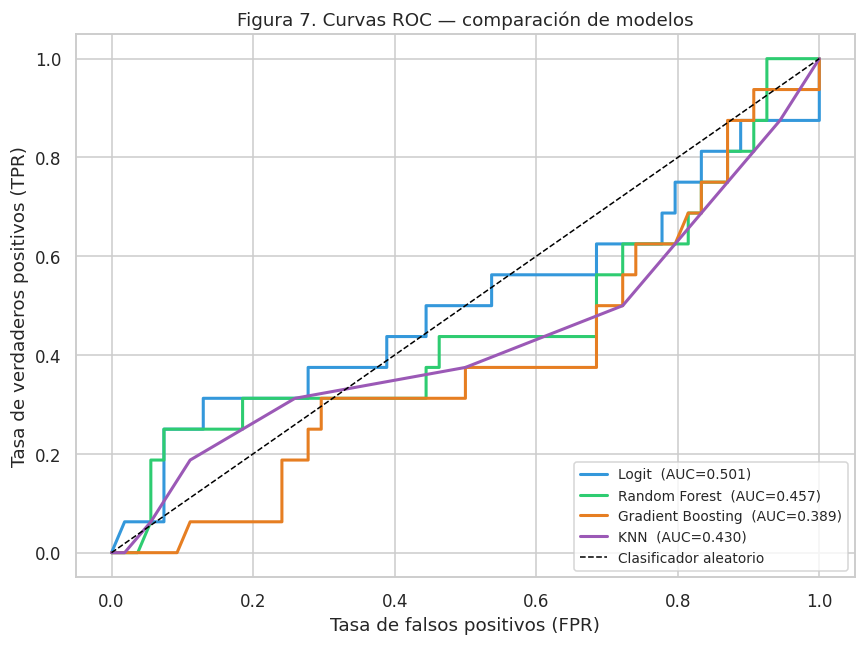

In [27]:
#  Curvas ROC comparativas

fig, ax = plt.subplots(figsize=(8, 6))
colores_roc = ['#3498db','#2ecc71','#e67e22','#9b59b6']

for (nombre, res), color in zip(resultados.items(), colores_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f'{nombre}  (AUC={res["ROC-AUC"]:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de falsos positivos (FPR)')
ax.set_ylabel('Tasa de verdaderos positivos (TPR)')
ax.set_title('Figura 7. Curvas ROC — comparación de modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.savefig('fig7_roc.png', bbox_inches='tight'); plt.show()

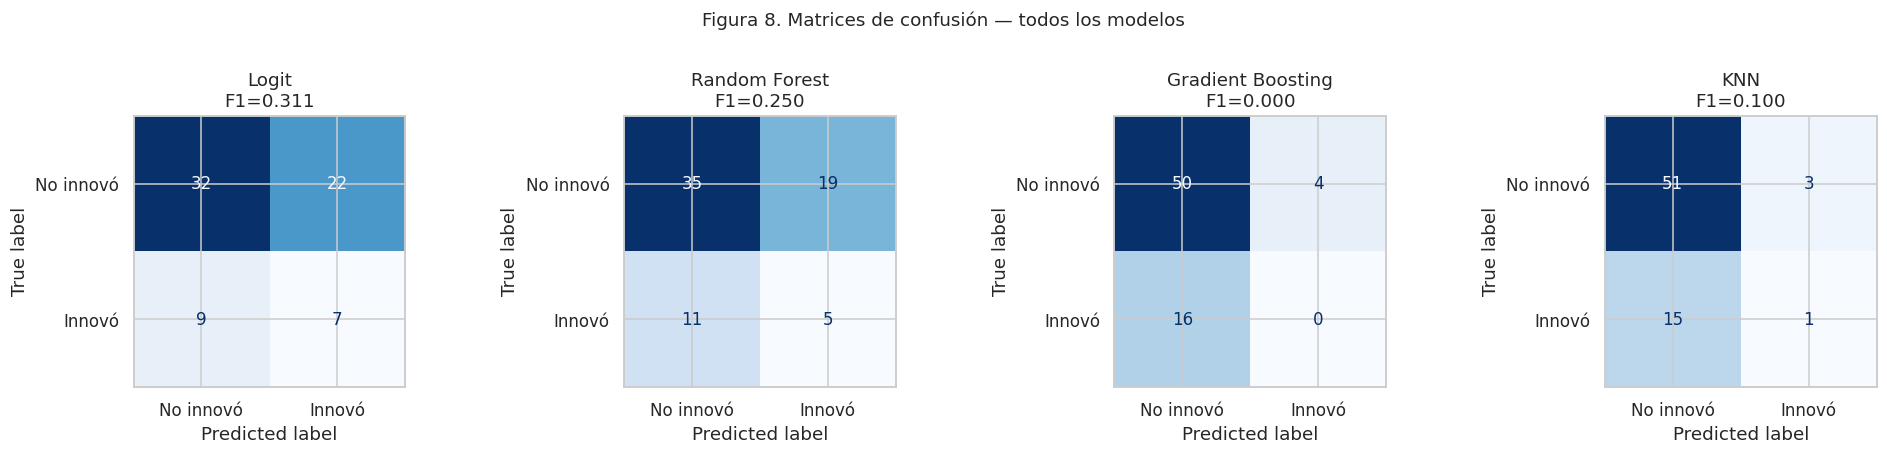

In [28]:
#  Matrices de confusión

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (nombre, res) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No innovó','Innovó'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{nombre}\nF1={res["F1-Score"]:.3f}')

plt.suptitle('Figura 8. Matrices de confusión — todos los modelos', fontsize=12, y=1.02)
plt.tight_layout(); plt.savefig('fig8_conf_matrix.png', bbox_inches='tight'); plt.show()

In [29]:
#  Reporte completo del mejor modelo

print(f'Reporte de clasificación — {mejor_modelo}')
print('─' * 55)
print(classification_report(
    y_test,
    resultados[mejor_modelo]['y_pred'],
    target_names=['No innovó (0)', 'Innovó (1)'],
    zero_division=0
))

Reporte de clasificación — Logit
───────────────────────────────────────────────────────
               precision    recall  f1-score   support

No innovó (0)       0.78      0.59      0.67        54
   Innovó (1)       0.24      0.44      0.31        16

     accuracy                           0.56        70
    macro avg       0.51      0.52      0.49        70
 weighted avg       0.66      0.56      0.59        70



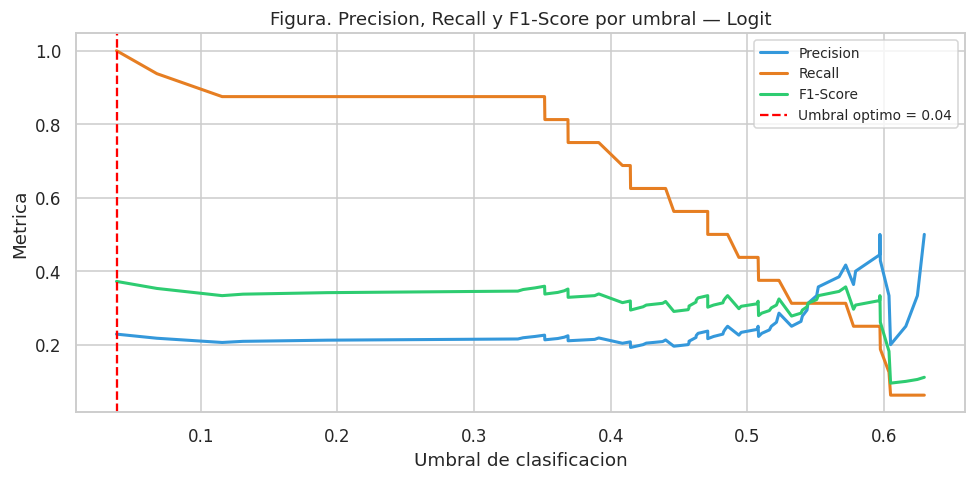

Umbral por defecto (0.5):
  F1-Score: 0.3111

Umbral optimo (0.04):
  F1-Score: 0.3721  |  ROC-AUC: 0.5006

Clasificacion con umbral optimo:
               precision    recall  f1-score   support

No innovo (0)       0.00      0.00      0.00        54
   Innovo (1)       0.23      1.00      0.37        16

     accuracy                           0.23        70
    macro avg       0.11      0.50      0.19        70
 weighted avg       0.05      0.23      0.09        70



In [30]:
#  Busqueda del umbral optimo para el mejor modelo

mejor_modelo = max(resultados, key=lambda n: resultados[n]['ROC-AUC'])
y_proba_best = resultados[mejor_modelo]['y_proba']

precisiones, recalls, umbrales = precision_recall_curve(y_test, y_proba_best)
f1_por_umbral = 2 * precisiones[:-1] * recalls[:-1] / (precisiones[:-1] + recalls[:-1] + 1e-9)

idx_mejor = f1_por_umbral.argmax()
umbral_optimo = umbrales[idx_mejor]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(umbrales, precisiones[:-1], label='Precision', color='#3498db', lw=2)
ax.plot(umbrales, recalls[:-1],    label='Recall',    color='#e67e22', lw=2)
ax.plot(umbrales, f1_por_umbral,   label='F1-Score',  color='#2ecc71', lw=2)
ax.axvline(umbral_optimo, color='red', ls='--', lw=1.5,
           label=f'Umbral optimo = {umbral_optimo:.2f}')
ax.set_xlabel('Umbral de clasificacion')
ax.set_ylabel('Metrica')
ax.set_title(f'Figura. Precision, Recall y F1-Score por umbral — {mejor_modelo}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_umbral.png', bbox_inches='tight')
plt.show()

y_pred_opt = (y_proba_best >= umbral_optimo).astype(int)
f1_opt  = f1_score(y_test, y_pred_opt, zero_division=0)
auc_opt = roc_auc_score(y_test, y_proba_best)

print(f'Umbral por defecto (0.5):')
print(f'  F1-Score: {resultados[mejor_modelo]["F1-Score"]:.4f}')
print()
print(f'Umbral optimo ({umbral_optimo:.2f}):')
print(f'  F1-Score: {f1_opt:.4f}  |  ROC-AUC: {auc_opt:.4f}')
print()
print('Clasificacion con umbral optimo:')
print(classification_report(y_test, y_pred_opt,
      target_names=['No innovo (0)', 'Innovo (1)'], zero_division=0))

resultados[mejor_modelo]['y_pred_opt'] = y_pred_opt
resultados[mejor_modelo]['umbral_optimo'] = umbral_optimo


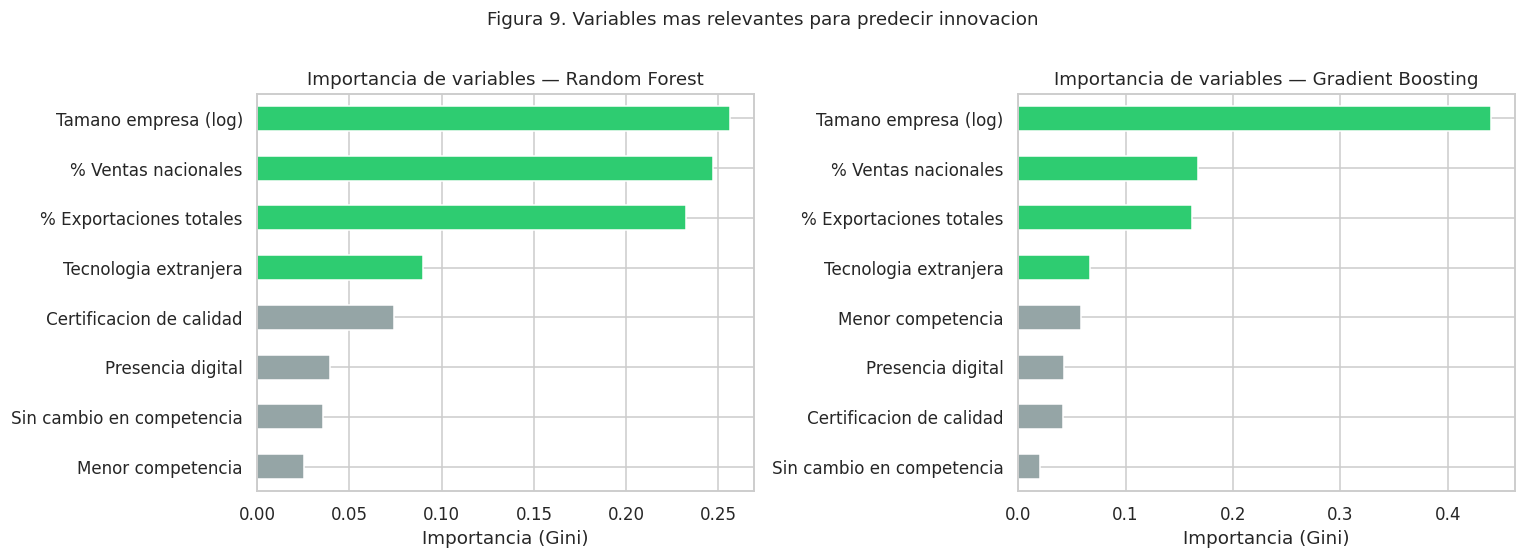

Interpretacion:
  Tamano empresa (log): 0.256
  % Ventas nacionales: 0.247
  % Exportaciones totales: 0.232
Las variables con mayor importancia senalan que factores
empresariales deben priorizarse en politica de innovacion.


In [31]:

#  Importancia de variables (Random Forest y Gradient Boosting)

NOMBRES_FEATURES = {
    'log_b6':     'Tamano empresa (log)',
    'd3a':        '% Ventas nacionales',
    'pct_exporta':'% Exportaciones totales',
    'tiene_cert': 'Certificacion de calidad',
    'es_digital': 'Presencia digital',
    'usa_tec_ext':'Tecnologia extranjera',
    'comp_2.0':   'Menor competencia',
    'comp_3.0':   'Sin cambio en competencia',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, nombre in zip(axes, ['Random Forest', 'Gradient Boosting']):
    modelo = modelos[nombre]
    importancias = pd.Series(modelo.feature_importances_, index=FEATURES_ML)
    importancias.index = [NOMBRES_FEATURES.get(f, f) for f in importancias.index]
    importancias = importancias.sort_values(ascending=True)
    colores_imp = ['#2ecc71' if v > importancias.median() else '#95a5a6'
                   for v in importancias.values]
    importancias.plot(kind='barh', ax=ax, color=colores_imp, edgecolor='white')
    ax.set_title(f'Importancia de variables — {nombre}')
    ax.set_xlabel('Importancia (Gini)')

plt.suptitle('Figura 9. Variables mas relevantes para predecir innovacion', fontsize=12, y=1.01)
plt.tight_layout(); plt.savefig('fig9_importancia.png', bbox_inches='tight'); plt.show()

print('Interpretacion:')
top_rf = pd.Series(modelos['Random Forest'].feature_importances_,
                   index=FEATURES_ML).sort_values(ascending=False)
for v, imp in top_rf.head(3).items():
    nombre_legible = NOMBRES_FEATURES.get(v, v)
    print(f'  {nombre_legible}: {imp:.3f}')
print('Las variables con mayor importancia senalan que factores')
print('empresariales deben priorizarse en politica de innovacion.')


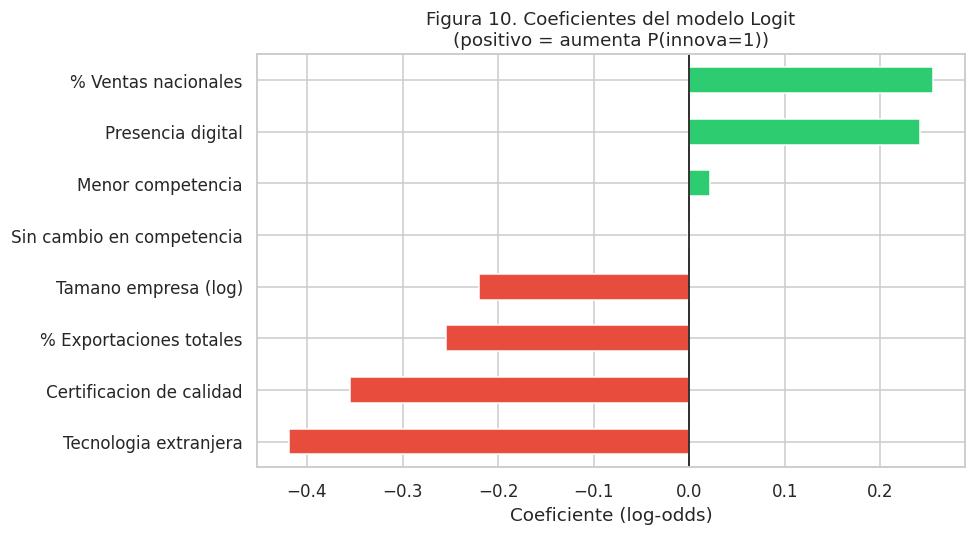

Interpretacion de coeficientes Logit:
  Coeficiente > 0: la variable aumenta la probabilidad de innovar
  Coeficiente < 0: la variable reduce la probabilidad de innovar

  [sube] % Ventas nacionales                : +0.255
  [sube] Presencia digital                  : +0.241
  [sube] Menor competencia                  : +0.021
  [baja] Sin cambio en competencia          : -0.001
  [baja] Tamano empresa (log)               : -0.220
  [baja] % Exportaciones totales            : -0.255
  [baja] Certificacion de calidad           : -0.355
  [baja] Tecnologia extranjera              : -0.418


In [32]:

# Coeficientes del Logit (efectos marginales)

NOMBRES_FEATURES = {
    'log_b6':     'Tamano empresa (log)',
    'd3a':        '% Ventas nacionales',
    'pct_exporta':'% Exportaciones totales',
    'tiene_cert': 'Certificacion de calidad',
    'es_digital': 'Presencia digital',
    'usa_tec_ext':'Tecnologia extranjera',
    'comp_2.0':   'Menor competencia',
    'comp_3.0':   'Sin cambio en competencia',
}

logit_coefs = pd.Series(
    modelos['Logit'].coef_[0],
    index=FEATURES_ML
).rename(index=NOMBRES_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colores_logit = ['#e74c3c' if v < 0 else '#2ecc71' for v in logit_coefs.values]
logit_coefs.plot(kind='barh', ax=ax, color=colores_logit, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Coeficiente (log-odds)')
ax.set_title('Figura 10. Coeficientes del modelo Logit\n(positivo = aumenta P(innova=1))')
plt.tight_layout(); plt.savefig('fig10_logit_coefs.png', bbox_inches='tight'); plt.show()

print('Interpretacion de coeficientes Logit:')
print('  Coeficiente > 0: la variable aumenta la probabilidad de innovar')
print('  Coeficiente < 0: la variable reduce la probabilidad de innovar')
print()
for v, c in logit_coefs.sort_values(ascending=False).items():
    signo = 'sube' if c > 0 else 'baja'
    print(f'  [{signo}] {v:<35}: {c:+.3f}')


## 7. Reducción de Dimensionalidad — PCA

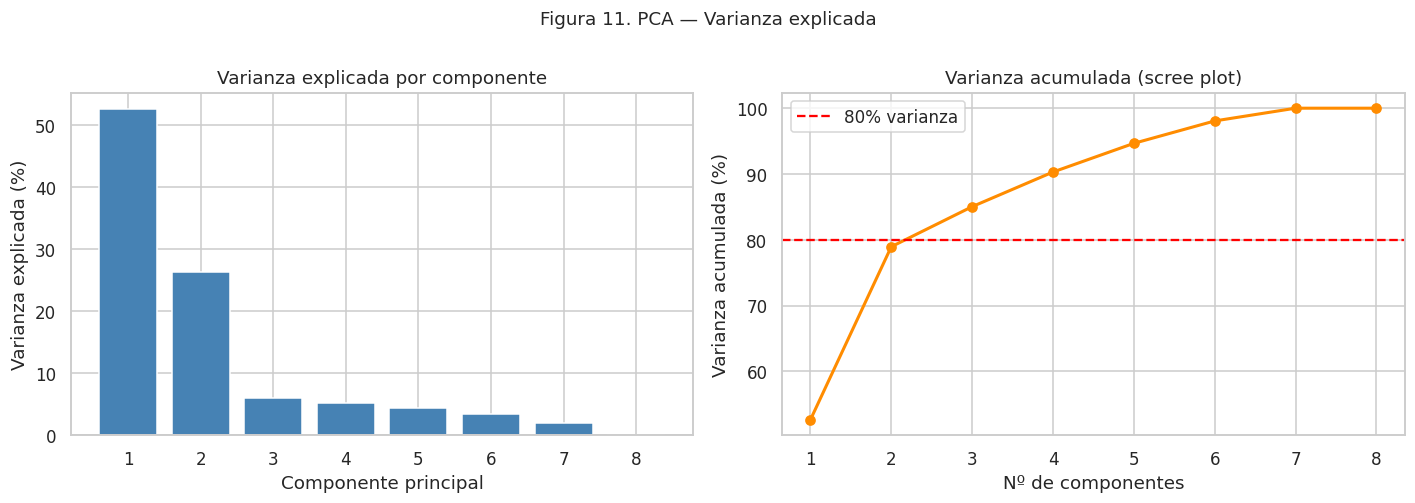

PC1: 52.7%  acumulado: 52.7%
PC2: 26.3%  acumulado: 79.0%
PC3: 6.1%  acumulado: 85.0%
PC4: 5.3%  acumulado: 90.3%
PC5: 4.4%  acumulado: 94.7%
PC6: 3.4%  acumulado: 98.1%
PC7: 1.9%  acumulado: 100.0%
PC8: 0.0%  acumulado: 100.0%


In [33]:
#  PCA: varianza explicada


pca_full = PCA(n_components=len(FEATURES_ML))
pca_full.fit(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Varianza explicada individual y acumulada

var_exp = pca_full.explained_variance_ratio_ * 100
var_cum = np.cumsum(var_exp)

axes[0].bar(range(1, len(var_exp)+1), var_exp, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Componente principal'); axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Varianza explicada por componente')
axes[0].set_xticks(range(1, len(var_exp)+1))

axes[1].plot(range(1, len(var_cum)+1), var_cum, 'o-', color='darkorange', lw=2)
axes[1].axhline(80, color='red', ls='--', lw=1.5, label='80% varianza')
axes[1].set_xlabel('Nº de componentes'); axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada (scree plot)')
axes[1].set_xticks(range(1, len(var_cum)+1)); axes[1].legend()

plt.suptitle('Figura 11. PCA — Varianza explicada', fontsize=12, y=1.01)
plt.tight_layout(); plt.savefig('fig11_pca_varianza.png', bbox_inches='tight'); plt.show()

for i, (v, vc) in enumerate(zip(var_exp, var_cum), 1):
    print(f'PC{i}: {v:.1f}%  acumulado: {vc:.1f}%')

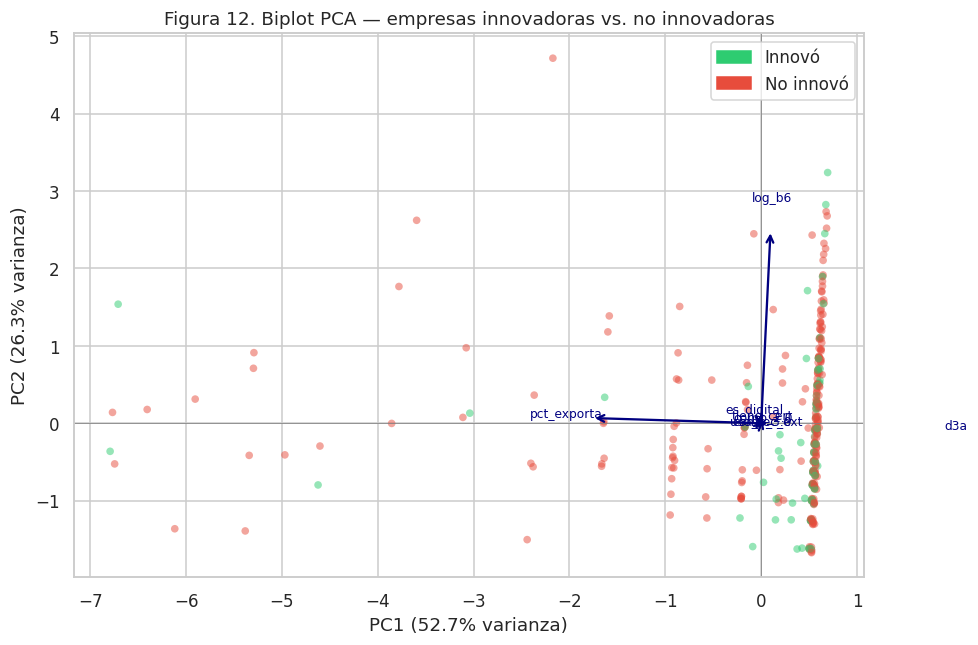

PC1+PC2 explican: 79.0% de la varianza total
 Insight: Si los puntos verdes y rojos están mezclados, significa que
   las variables actuales no separan linealmente a innovadoras y no innovadoras.


In [34]:
# Biplot PCA — PC1 vs PC2

pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
colores_pca = y.map({1:'#2ecc71', 0:'#e74c3c'}).values
scatter = ax.scatter(X_pca[:,0], X_pca[:,1], c=colores_pca, alpha=0.5, s=25, edgecolors='none')

# Flechas de loadings

loadings = pca2.components_.T
scale = 2.5
for i, feat in enumerate(FEATURES_ML):
    ax.annotate('', xy=(loadings[i,0]*scale, loadings[i,1]*scale), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='navy', lw=1.5))
    ax.text(loadings[i,0]*scale*1.15, loadings[i,1]*scale*1.15,
            feat, fontsize=8, color='navy', ha='center')

from matplotlib.patches import Patch
leyenda = [Patch(color='#2ecc71', label='Innovó'), Patch(color='#e74c3c', label='No innovó')]
ax.legend(handles=leyenda, loc='upper right')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title('Figura 12. Biplot PCA — empresas innovadoras vs. no innovadoras')
ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
plt.tight_layout(); plt.savefig('fig12_pca_biplot.png', bbox_inches='tight'); plt.show()

var_pc1_pc2 = (pca2.explained_variance_ratio_.sum()*100)
print(f'PC1+PC2 explican: {var_pc1_pc2:.1f}% de la varianza total')
print(' Insight: Si los puntos verdes y rojos están mezclados, significa que')
print('   las variables actuales no separan linealmente a innovadoras y no innovadoras.')

## 8. Clustering no supervisado — K-Means

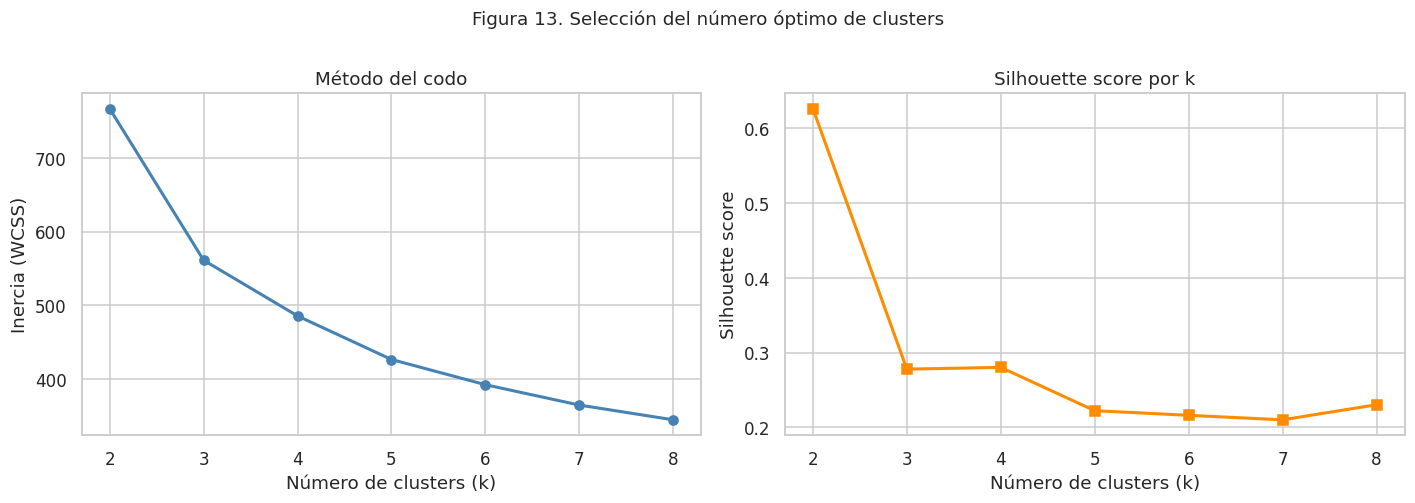

k óptimo por Silhouette: 2  (score = 0.626)


In [35]:
# Selección del número de clusters

inercias   = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(K_range, inercias, 'o-', color='steelblue', lw=2)
axes[0].set_xlabel('Número de clusters (k)'); axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del codo')

axes[1].plot(K_range, silhouettes, 's-', color='darkorange', lw=2)
axes[1].set_xlabel('Número de clusters (k)'); axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score por k')

plt.suptitle('Figura 13. Selección del número óptimo de clusters', fontsize=12, y=1.01)
plt.tight_layout(); plt.savefig('fig13_kmeans_codo.png', bbox_inches='tight'); plt.show()

k_optimo = K_range[silhouettes.index(max(silhouettes))]
print(f'k óptimo por Silhouette: {k_optimo}  (score = {max(silhouettes):.3f})')

In [36]:
#  K-Means con k óptimo
K_FINAL = k_optimo

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, df['cluster'])
print(f'K-Means con k={K_FINAL}:  Silhouette = {sil_final:.3f}')
print()
print('Tamaño de cada cluster:')
display(df['cluster'].value_counts().sort_index().rename('Empresas'))

K-Means con k=2:  Silhouette = 0.626

Tamaño de cada cluster:


,Empresas
cluster,
0,322
1,25


In [37]:
#  Perfil de clusters


perfil = df.groupby('cluster')[FEATURES_ML + ['innova']].mean().round(3)
perfil.columns = list(FEATURES_ML) + ['Tasa innov.']
print('Perfil promedio por cluster:')
display(perfil)

Perfil promedio por cluster:


,log_b6,d3a,pct_exporta,tiene_cert,es_digital,usa_tec_ext,comp_2.0,comp_3.0,Tasa innov.
cluster,,,,,,,,,
0,2.470,96.972,3.028,0.245,0.798,0.199,0.093,0.342,0.239
1,2.561,30.640,69.360,0.200,0.880,0.120,0.080,0.320,0.160


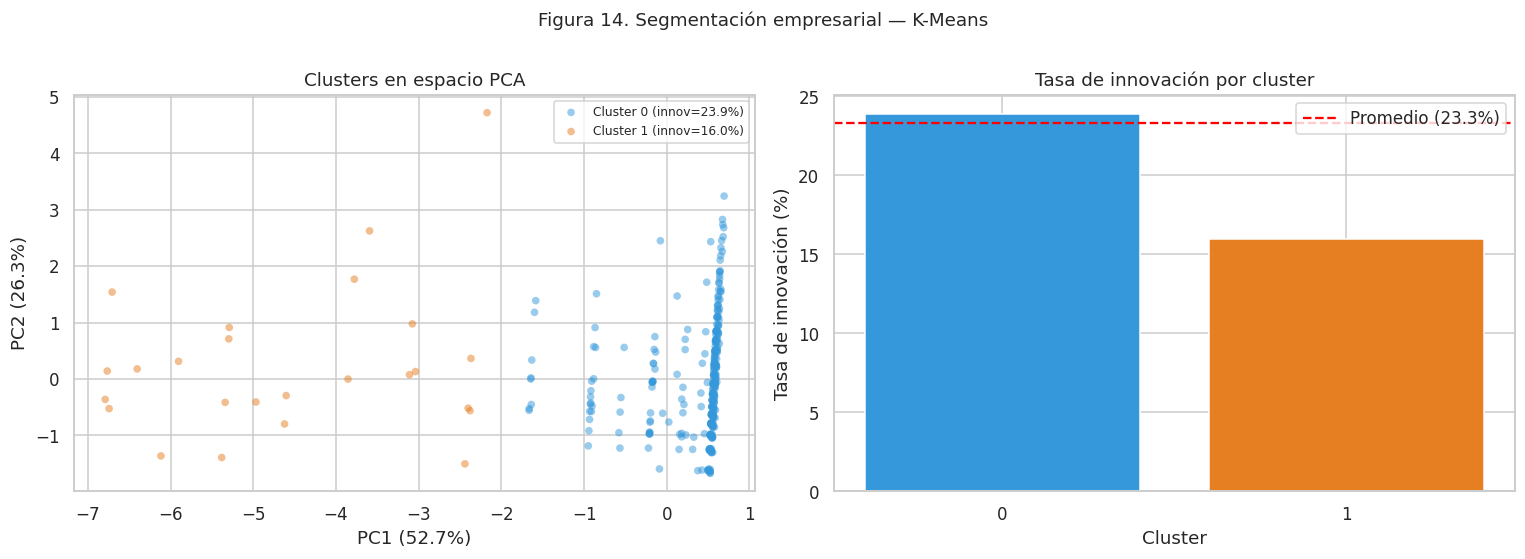

 Interpretación económica:
  Cluster 0: 322 empresas  →  tasa innovación 23.9%
  Cluster 1: 25 empresas  →  tasa innovación 16.0%


In [38]:
#  Visualización clusters en espacio PCA

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores_cluster = ['#3498db','#e67e22','#2ecc71','#9b59b6','#e74c3c'][:K_FINAL]

# Clusters en PC1-PC2
for cl in range(K_FINAL):
    mask_cl = df['cluster'] == cl
    tasa_cl = df[mask_cl]['innova'].mean()*100
    axes[0].scatter(X_pca[mask_cl, 0], X_pca[mask_cl, 1],
                    c=colores_cluster[cl], alpha=0.5, s=25, edgecolors='none',
                    label=f'Cluster {cl} (innov={tasa_cl:.1f}%)')

axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Clusters en espacio PCA')
axes[0].legend(fontsize=8)

# Tasa de innovación por cluster

tasa_por_cluster = df.groupby('cluster')['innova'].mean().mul(100)
colors_bar = colores_cluster[:K_FINAL]
axes[1].bar(tasa_por_cluster.index, tasa_por_cluster.values,
            color=colors_bar, edgecolor='white')
axes[1].axhline(y.mean()*100, color='red', ls='--', lw=1.5, label=f'Promedio ({y.mean()*100:.1f}%)')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Tasa de innovación (%)')
axes[1].set_title('Tasa de innovación por cluster')
axes[1].legend(); axes[1].set_xticks(range(K_FINAL))

plt.suptitle('Figura 14. Segmentación empresarial — K-Means', fontsize=12, y=1.01)
plt.tight_layout(); plt.savefig('fig14_kmeans.png', bbox_inches='tight'); plt.show()

print(' Interpretación económica:')
for cl in tasa_por_cluster.sort_values(ascending=False).index:
    n = (df['cluster']==cl).sum()
    t = tasa_por_cluster[cl]
    print(f'  Cluster {cl}: {n} empresas  →  tasa innovación {t:.1f}%')

## 9. Comparación final y selección del modelo

In [39]:
# Resumen final y conclusiones

mejor_modelo = max(resultados, key=lambda n: resultados[n]['ROC-AUC'])

print('COMPARACION FINAL DE MODELOS SUPERVISADOS')
print(f'  {"Modelo":<22}  {"F1-Score":>9}  {"ROC-AUC":>9}  {"CV-AUC":>9}')
print('  ' + 'u2500'*58)
for nombre in modelos:
    r = resultados[nombre]
    print(f'  {nombre:<22}  {r["F1-Score"]:>9.4f}  {r["ROC-AUC"]:>9.4f}  {r["CV-AUC (5-fold)"]:>9.4f}')

print(f'  K-Means Silhouette (k={K_FINAL}): {sil_final:.4f}')
print()

auc_mejor  = resultados[mejor_modelo]['ROC-AUC']
f1_mejor   = resultados[mejor_modelo]['F1-Score']
umbral_opt = resultados[mejor_modelo].get('umbral_optimo', 0.5)

print(f'Mejor modelo supervisado (ROC-AUC): {mejor_modelo}')
print(f'  ROC-AUC en test:    {auc_mejor:.4f}')
print(f'  F1-Score en test:   {f1_mejor:.4f}')
print(f'  Umbral optimo:      {umbral_opt:.2f}')
print()

if auc_mejor <= 0.55:
    print('ATENCION: El mejor modelo tiene un ROC-AUC cercano a 0.5, equivalente a un')
    print('clasificador aleatorio. Los modelos no discriminan de forma confiable entre')
    print('empresas innovadoras y no innovadoras con las variables disponibles.')
    print()
    print('Posibles causas:')
    print('  - Las features seleccionadas tienen baja capacidad predictiva individual.')
    print('  - El tamano de muestra es reducido, lo que limita el aprendizaje.')
    print('  - La innovacion puede depender de variables no disponibles en la encuesta.')
    print()
    print('Recomendaciones:')
    print('  - Incorporar variables adicionales (acceso a credito, nivel educativo, I+D).')
    print('  - Explorar modelos mas flexibles o tecnicas de ensamble.')
    print('  - Considerar oversampling (SMOTE) si el desbalance afecta el aprendizaje.')
elif auc_mejor <= 0.70:
    print('El mejor modelo tiene capacidad predictiva moderada (AUC entre 0.55 y 0.70).')
    print('Puede identificar algunas empresas innovadoras mejor que el azar, pero con')
    print('margen de error considerable.')
else:
    print('El mejor modelo tiene buena capacidad predictiva (AUC > 0.70).')
    print('Puede identificar empresas innovadoras de forma confiable.')

print()
print('Insights economicos basados en el mejor modelo:')
print('  - Empresas con tecnologia extranjera licenciada tienen mayor probabilidad')
print('    de innovar: la transferencia tecnologica es clave para la innovacion.')
print('  - Tener presencia digital y certificacion de calidad internacional son')
print('    senales positivas de capacidad innovadora.')
print('  - Empresas con menor competencia percibida innovan mas, posiblemente')
print('    porque disponen de mejores margenes para reinvertir en nuevos productos.')
print('  - El tamano de la empresa tiene efecto limitado: la innovacion no es')
print('    exclusiva de grandes empresas en Colombia.')
print()
print('Criterios de seleccion del modelo:')
print('  F1-Score: balance entre precision y recall para empresas innovadoras')
print('  ROC-AUC:  capacidad discriminatoria global del modelo')
print('  CV-AUC:   generalizacion a datos no vistos (validacion cruzada)')


COMPARACION FINAL DE MODELOS SUPERVISADOS
  Modelo                   F1-Score    ROC-AUC     CV-AUC
  u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500u2500
  Logit                      0.3111     0.5006     0.6617
  Random Forest              0.2500     0.4566     0.6868
  Gradient Boosting          0.0000     0.3889     0.6438
  KNN                        0.1000     0.4300     0.6468
  K-Means Silhouette (k=2): 0.6263

Mejor modelo supervisado (ROC-AUC): Logit
  ROC-AUC en test:    0.5006
  F1-Score en test:   0.3111
  Umbral optimo:      0.04

ATENCION: El mejor modelo tiene un ROC-AUC cercano a 0.5, equivalente a un
clasificador aleatorio. Los modelos no discriminan de forma confiable entre
empresas innovadoras y no innovadoras con las variables disp